In [ ]:
# imports
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import numpy as np
from itertools import combinations

In [6]:
# Função genérica para calcular e exibir os gráficos de TF-IDF e BoW
def generate_dual_similarity_heatmaps(vectorizer, corpus, title, top_n=30, cmap_sim="Blues", cmap_diff="Reds"):
    X = vectorizer.fit_transform(corpus)
    sim_matrix = cosine_similarity(X)

    # Remover diagonal
    np.fill_diagonal(sim_matrix, np.nan)

    # Combinações de pares
    indices = np.array(list(combinations(range(sim_matrix.shape[0]), 2)))
    values = np.array([sim_matrix[i, j] for i, j in indices])

    # Top similares
    top_sim_idx = np.argsort(values)[-top_n:]
    top_sim_pairs = indices[top_sim_idx]

    # Top diferentes
    top_diff_idx = np.argsort(values)[:top_n]
    top_diff_pairs = indices[top_diff_idx]

    def build_matrix(pairs):
        unique_idx = np.unique(pairs)
        return sim_matrix[np.ix_(unique_idx, unique_idx)]

    sim_sub = build_matrix(top_sim_pairs)
    diff_sub = build_matrix(top_diff_pairs)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(sim_sub, ax=axes[0], cmap=cmap_sim)
    axes[0].set_title(f"{title} - Top {top_n} Similar")

    sns.heatmap(diff_sub, ax=axes[1], cmap=cmap_diff)
    axes[1].set_title(f"{title} - Top {top_n} Different")

    plt.tight_layout()
    plt.show()

In [7]:
# Funções de visualização (TF-IDF e BoW)

def generate_tfidf_heatmap(corpus, title):
    generate_dual_similarity_heatmaps(
        TfidfVectorizer(),
        corpus,
        title,
        top_n=30,
        cmap_sim="Blues",
        cmap_diff="Reds"
    )


def generate_bow_heatmap(corpus, title):
    generate_dual_similarity_heatmaps(
        CountVectorizer(),
        corpus,
        title,
        top_n=30,
        cmap_sim="Greens",
        cmap_diff="Oranges"
    )

In [ ]:
def generate_word2vec_heatmap(corpus, title, top_n=30):
    # Tokenização (reaproveite seu pipeline se quiser)
    documentos_tokenizados = [doc.split() for doc in corpus]

    # Treinar modelo
    model_w2v = Word2Vec(
        sentences=documentos_tokenizados,
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        sg=0
    )

    # Vetor médio por documento
    vetores_documentos = []
    for doc_tokens in documentos_tokenizados:
        vetores_palavras = [
            model_w2v.wv[p] for p in doc_tokens if p in model_w2v.wv
        ]

        if vetores_palavras:
            vetores_documentos.append(np.mean(vetores_palavras, axis=0))
        else:
            vetores_documentos.append(np.zeros(model_w2v.vector_size))

    vetores_documentos = np.array(vetores_documentos)

    # Similaridade
    sim_matrix = cosine_similarity(vetores_documentos)

    np.fill_diagonal(sim_matrix, np.nan)

    indices = np.array(list(combinations(range(sim_matrix.shape[0]), 2)))
    values = np.array([sim_matrix[i, j] for i, j in indices])

    # Top similares
    top_sim_idx = np.argsort(values)[-top_n:]
    top_sim_pairs = indices[top_sim_idx]

    # Top diferentes
    top_diff_idx = np.argsort(values)[:top_n]
    top_diff_pairs = indices[top_diff_idx]

    def build_matrix(pairs):
        unique_idx = np.unique(pairs)
        return sim_matrix[np.ix_(unique_idx, unique_idx)]

    sim_sub = build_matrix(top_sim_pairs)
    diff_sub = build_matrix(top_diff_pairs)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(sim_sub, ax=axes[0], cmap="Purples")
    axes[0].set_title(f"{title} - Top {top_n} Similar")

    sns.heatmap(diff_sub, ax=axes[1], cmap="Oranges")
    axes[1].set_title(f"{title} - Top {top_n} Different")

    plt.tight_layout()
    plt.show()

In [ ]:
# Lista de pipelines

pipelines = [
    "lower_stop",
    "lower_stop_lemma",
    "lower_stop_stem"
]

Gerando BoW para: lower_stop


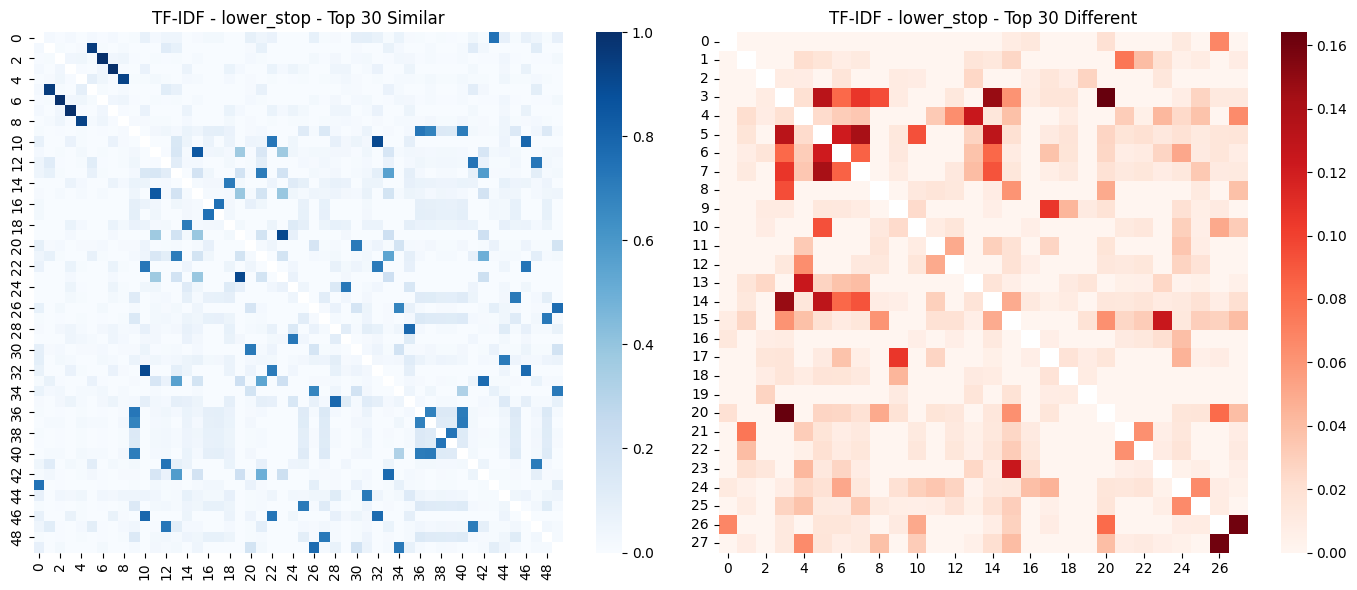

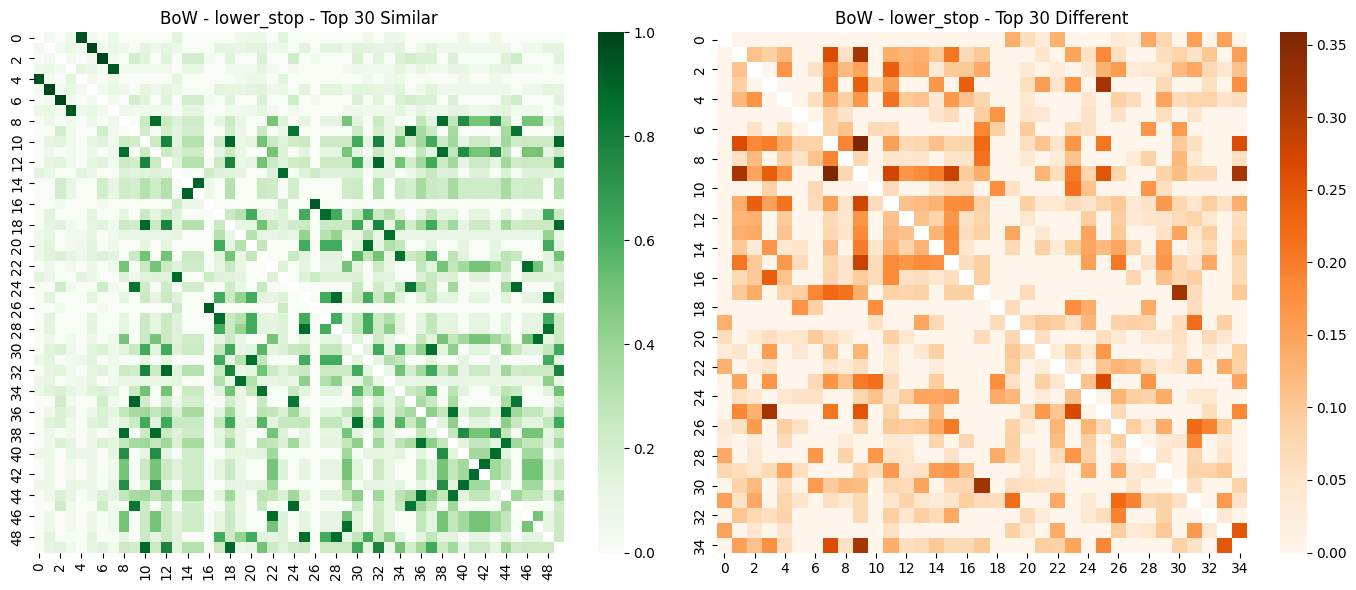

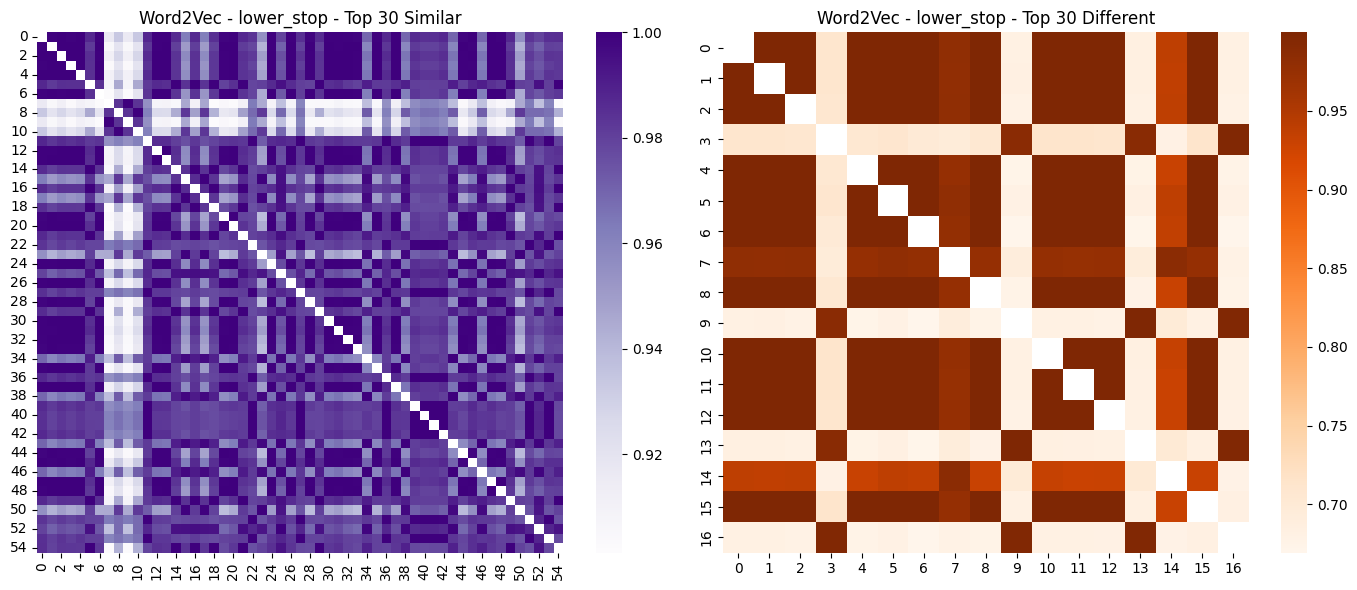

Gerando BoW para: lower_stop_lemma


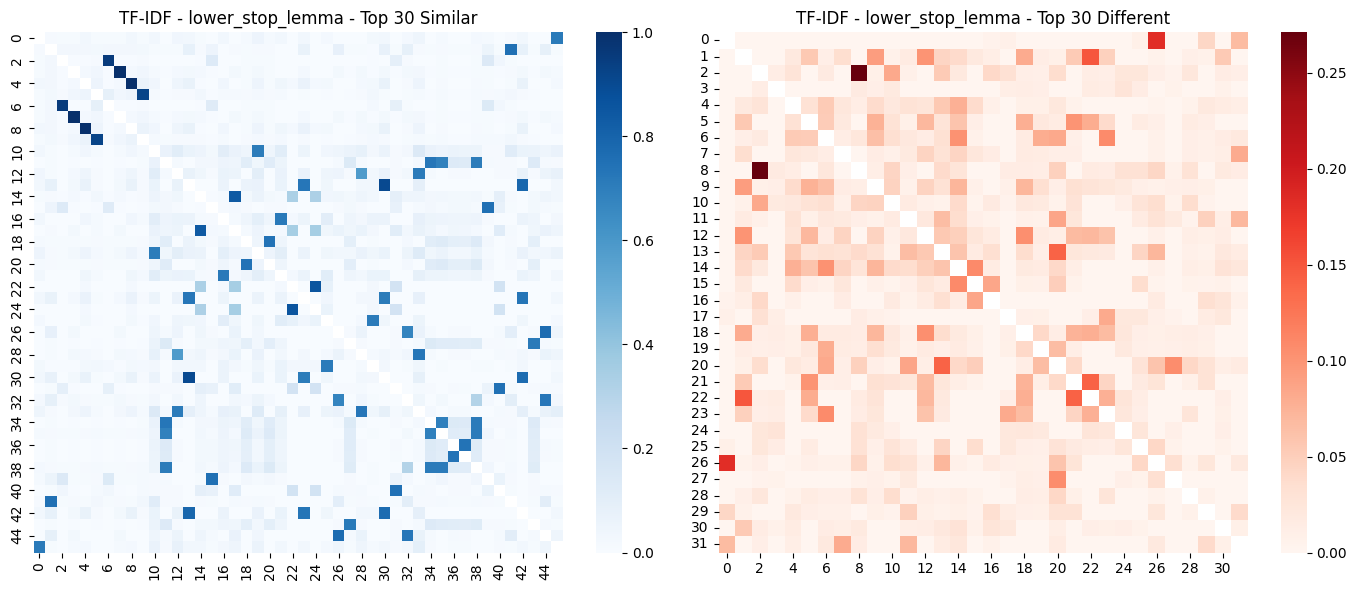

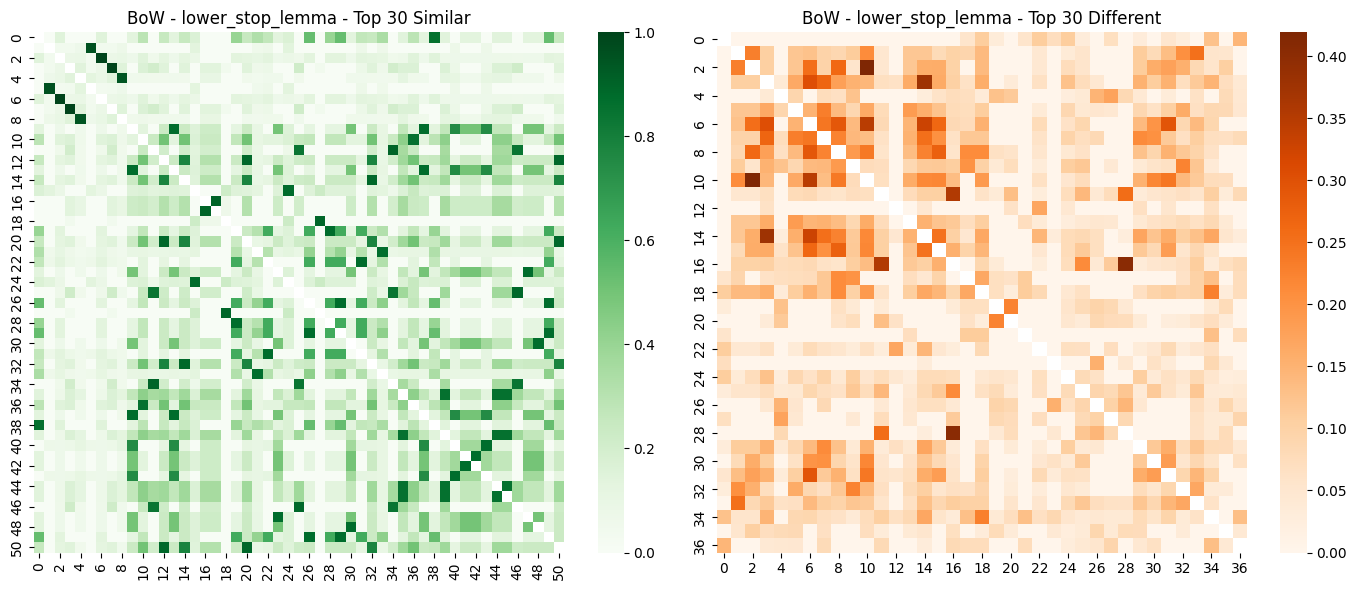

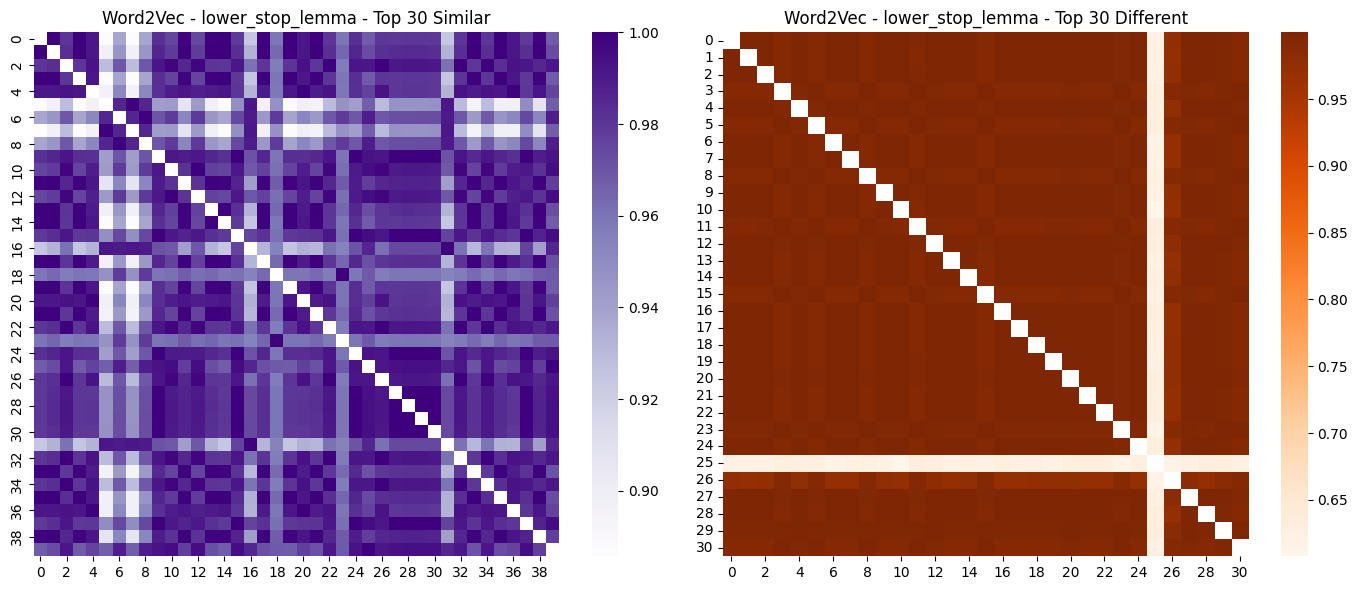

Gerando BoW para: lower_stop_stem


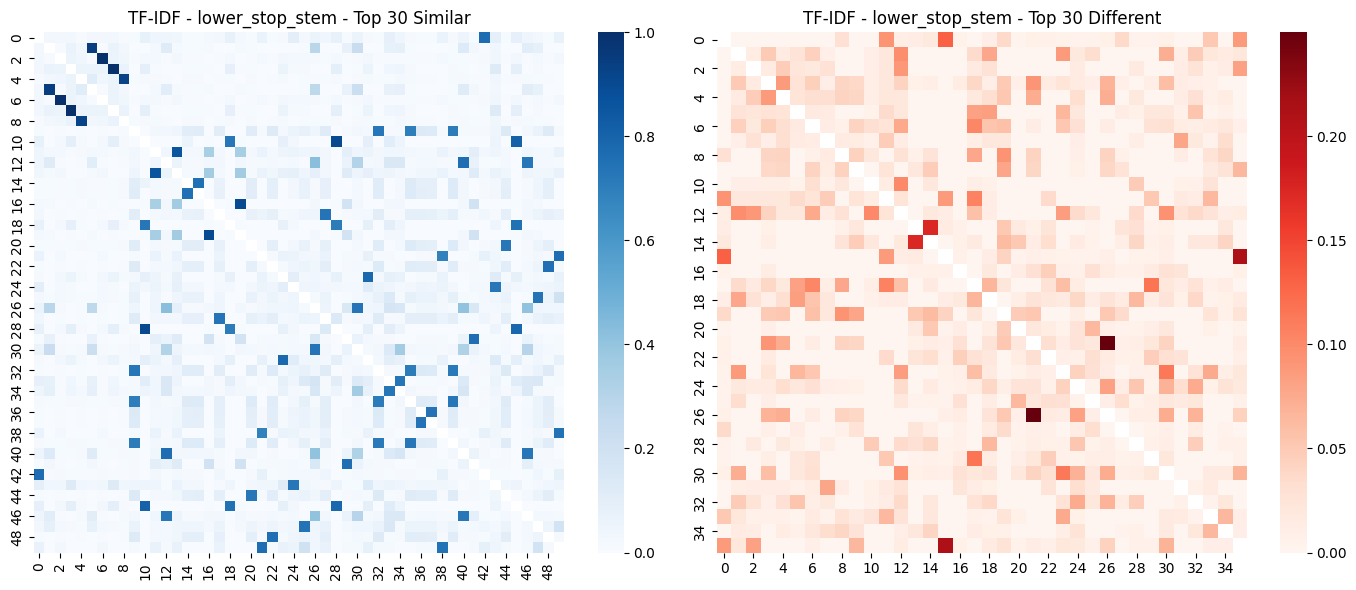

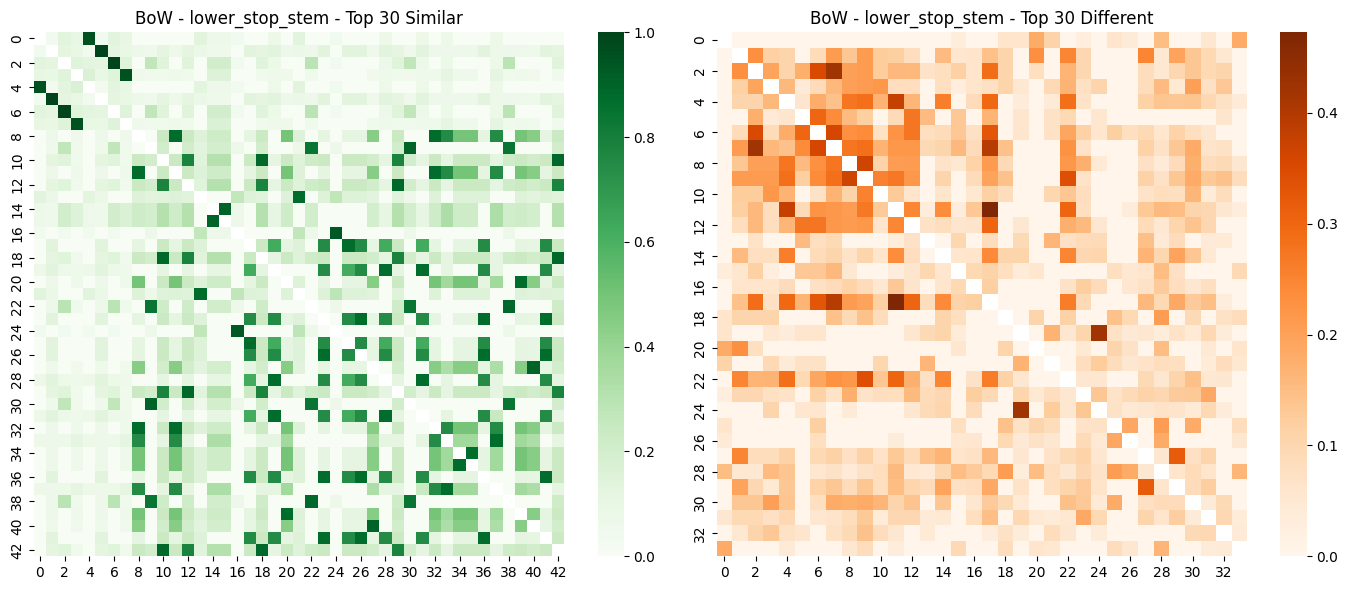

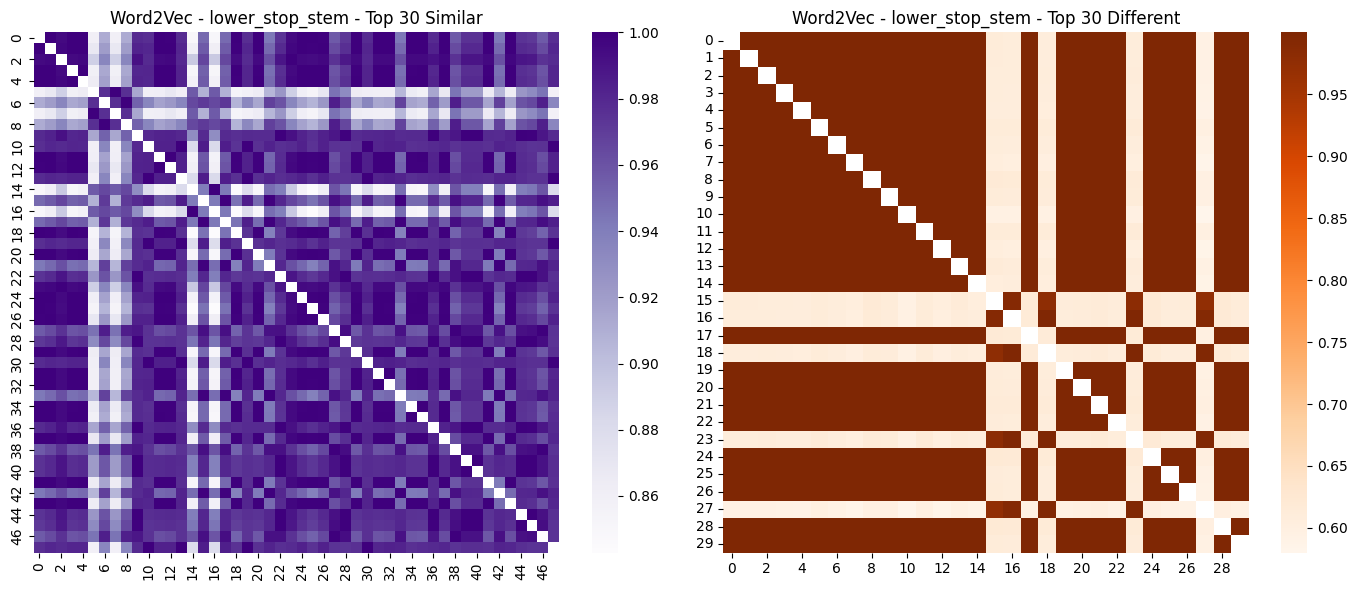

In [ ]:
# Gerar heatmaps BoW - TD-IDF - Words2Vec

for col in pipelines:
    print(f"Gerando BoW para: {col}")
    generate_tfidf_heatmap(df[col], f"TF-IDF - {col}")
    generate_bow_heatmap(df[col], f"BoW - {col}")
    generate_word2vec_heatmap(df[col], f"Word2Vec - {col}")